In [ ]:
!nvidia-smi

Sat Apr 25 05:37:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv8

⚠️ YOLOv8 is still under heavy development. Breaking changes are being introduced almost weekly. We strive to make our YOLOv8 notebooks work with the latest version of the library. Last tests took place on **18.01.2023** with version **YOLOv8.0.9**.

If you notice that our notebook behaves incorrectly - especially if you experience errors that prevent you from going through the tutorial - don't hesitate! Let us know and open an [issue](https://github.com/roboflow/notebooks/issues) on the Roboflow Notebooks repository.

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [6]:
# Pip install method (recommended)

!pip install ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)


In [7]:
from ultralytics import YOLO

from IPython.display import display, Image

## CLI Basics

If you want to train, validate or run inference on models and don't need to make any modifications to the code, using YOLO command line interface is the easiest way to get started. Read more about CLI in [Ultralytics YOLO Docs](https://v8docs.ultralytics.com/cli/).

```
yolo task=detect    mode=train    model=yolov8n.yaml      args...
          classify       predict        yolov8n-cls.yaml  args...
          segment        val            yolov8n-seg.yaml  args...
                         export         yolov8n.pt        format=onnx  args...
```

## Inference with Pre-trained COCO Model

### 💻 CLI

`yolo mode=predict` runs YOLOv8 inference on a variety of sources, downloading models automatically from the latest YOLOv8 release, and saving results to `runs/predict`.

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg'

/content
100% 6.23M/6.23M [00:00<00:00, 21.6MB/s]

Ultralytics YOLOv8.0.20 🚀 Python-3.8.10 torch-1.13.1+cu116 CUDA:0 (Tesla T4, 15110MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs
100% 104k/104k [00:00<00:00, 5.08MB/s]
image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 15.8ms
Speed: 0.6ms pre-process, 15.8ms inference, 48.7ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
# %cd {HOME}
# Image(filename='runs/detect/predict/dog.jpeg', height=600)

### 🐍 Python SDK

The simplest way of simply using YOLOv8 directly in a Python environment.

In [ ]:
model = YOLO(f'{HOME}/yolov8n.pt')
results = model.predict(source='https://media.roboflow.com/notebooks/examples/dog.jpeg', conf=0.25)

Ultralytics YOLOv8.0.20 🚀 Python-3.8.10 torch-1.13.1+cu116 CUDA:0 (Tesla T4, 15110MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs
Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg


In [ ]:
results[0].boxes.xyxy

tensor([[   0.,  314.,  625., 1278.],
        [  55.,  250.,  648., 1266.],
        [ 633.,  720.,  701.,  786.]], device='cuda:0')

In [ ]:
results[0].boxes.conf

tensor([0.72712, 0.29066, 0.28456], device='cuda:0')

In [ ]:
results[0].boxes.cls

tensor([ 0., 16.,  2.], device='cuda:0')

## Custom Training

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Computer vision/Day 23

/content/drive/MyDrive/Computer vision/Day 23


In [3]:
%pwd

'/content/drive/MyDrive/Computer vision/Day 23'

In [4]:
%ls

data.yaml  test/   yolo26n.pt                                       yolov8s.pt
data.zip   train/  YOLO_v8_CMD.ipynb
runs/      valid/  Yolov8_object_detection_on_custom_dataset.ipynb


In [ ]:
!unzip data.zip

Archive:  data.zip
  inflating: data.yaml               
   creating: test/
   creating: test/images/
  inflating: test/images/1.jpeg      
  inflating: test/images/10.jpeg     
  inflating: test/images/11.jpeg     
  inflating: test/images/12.jpeg     
  inflating: test/images/13.jpeg     
  inflating: test/images/14(1).jpeg  
  inflating: test/images/14.jpg      
  inflating: test/images/15.jpeg     
  inflating: test/images/16.jpeg     
  inflating: test/images/17.jpeg     
  inflating: test/images/18.jpeg     
  inflating: test/images/19.jpeg     
  inflating: test/images/2.jpeg      
  inflating: test/images/20.jpeg     
  inflating: test/images/21.jpeg     
  inflating: test/images/22.jpeg     
  inflating: test/images/23.jpeg     
  inflating: test/images/24.jpeg     
  inflating: test/images/25.jpeg     
  inflating: test/images/26.jpeg     
  inflating: test/images/27.jpeg     
  inflating: test/images/28.jpeg     
  inflating: test/images/29.jpeg     
  inflating: test/images

In [ ]:
%ls

data.yaml  train/             Yolov8_object_detection_on_custom_dataset.ipynb
data.zip   valid/
test/      YOLO_v8_CMD.ipynb


In [ ]:
%cd /content/drive/MyDrive/Computer vision/Day 23

!yolo task=detect mode=train model=yolov8s.pt data= data.yaml epochs=25 imgsz=224 plots=True

/content/drive/MyDrive/Computer vision/Day 23
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [ ]:
!ls runs/detect/train/

args.yaml  weights


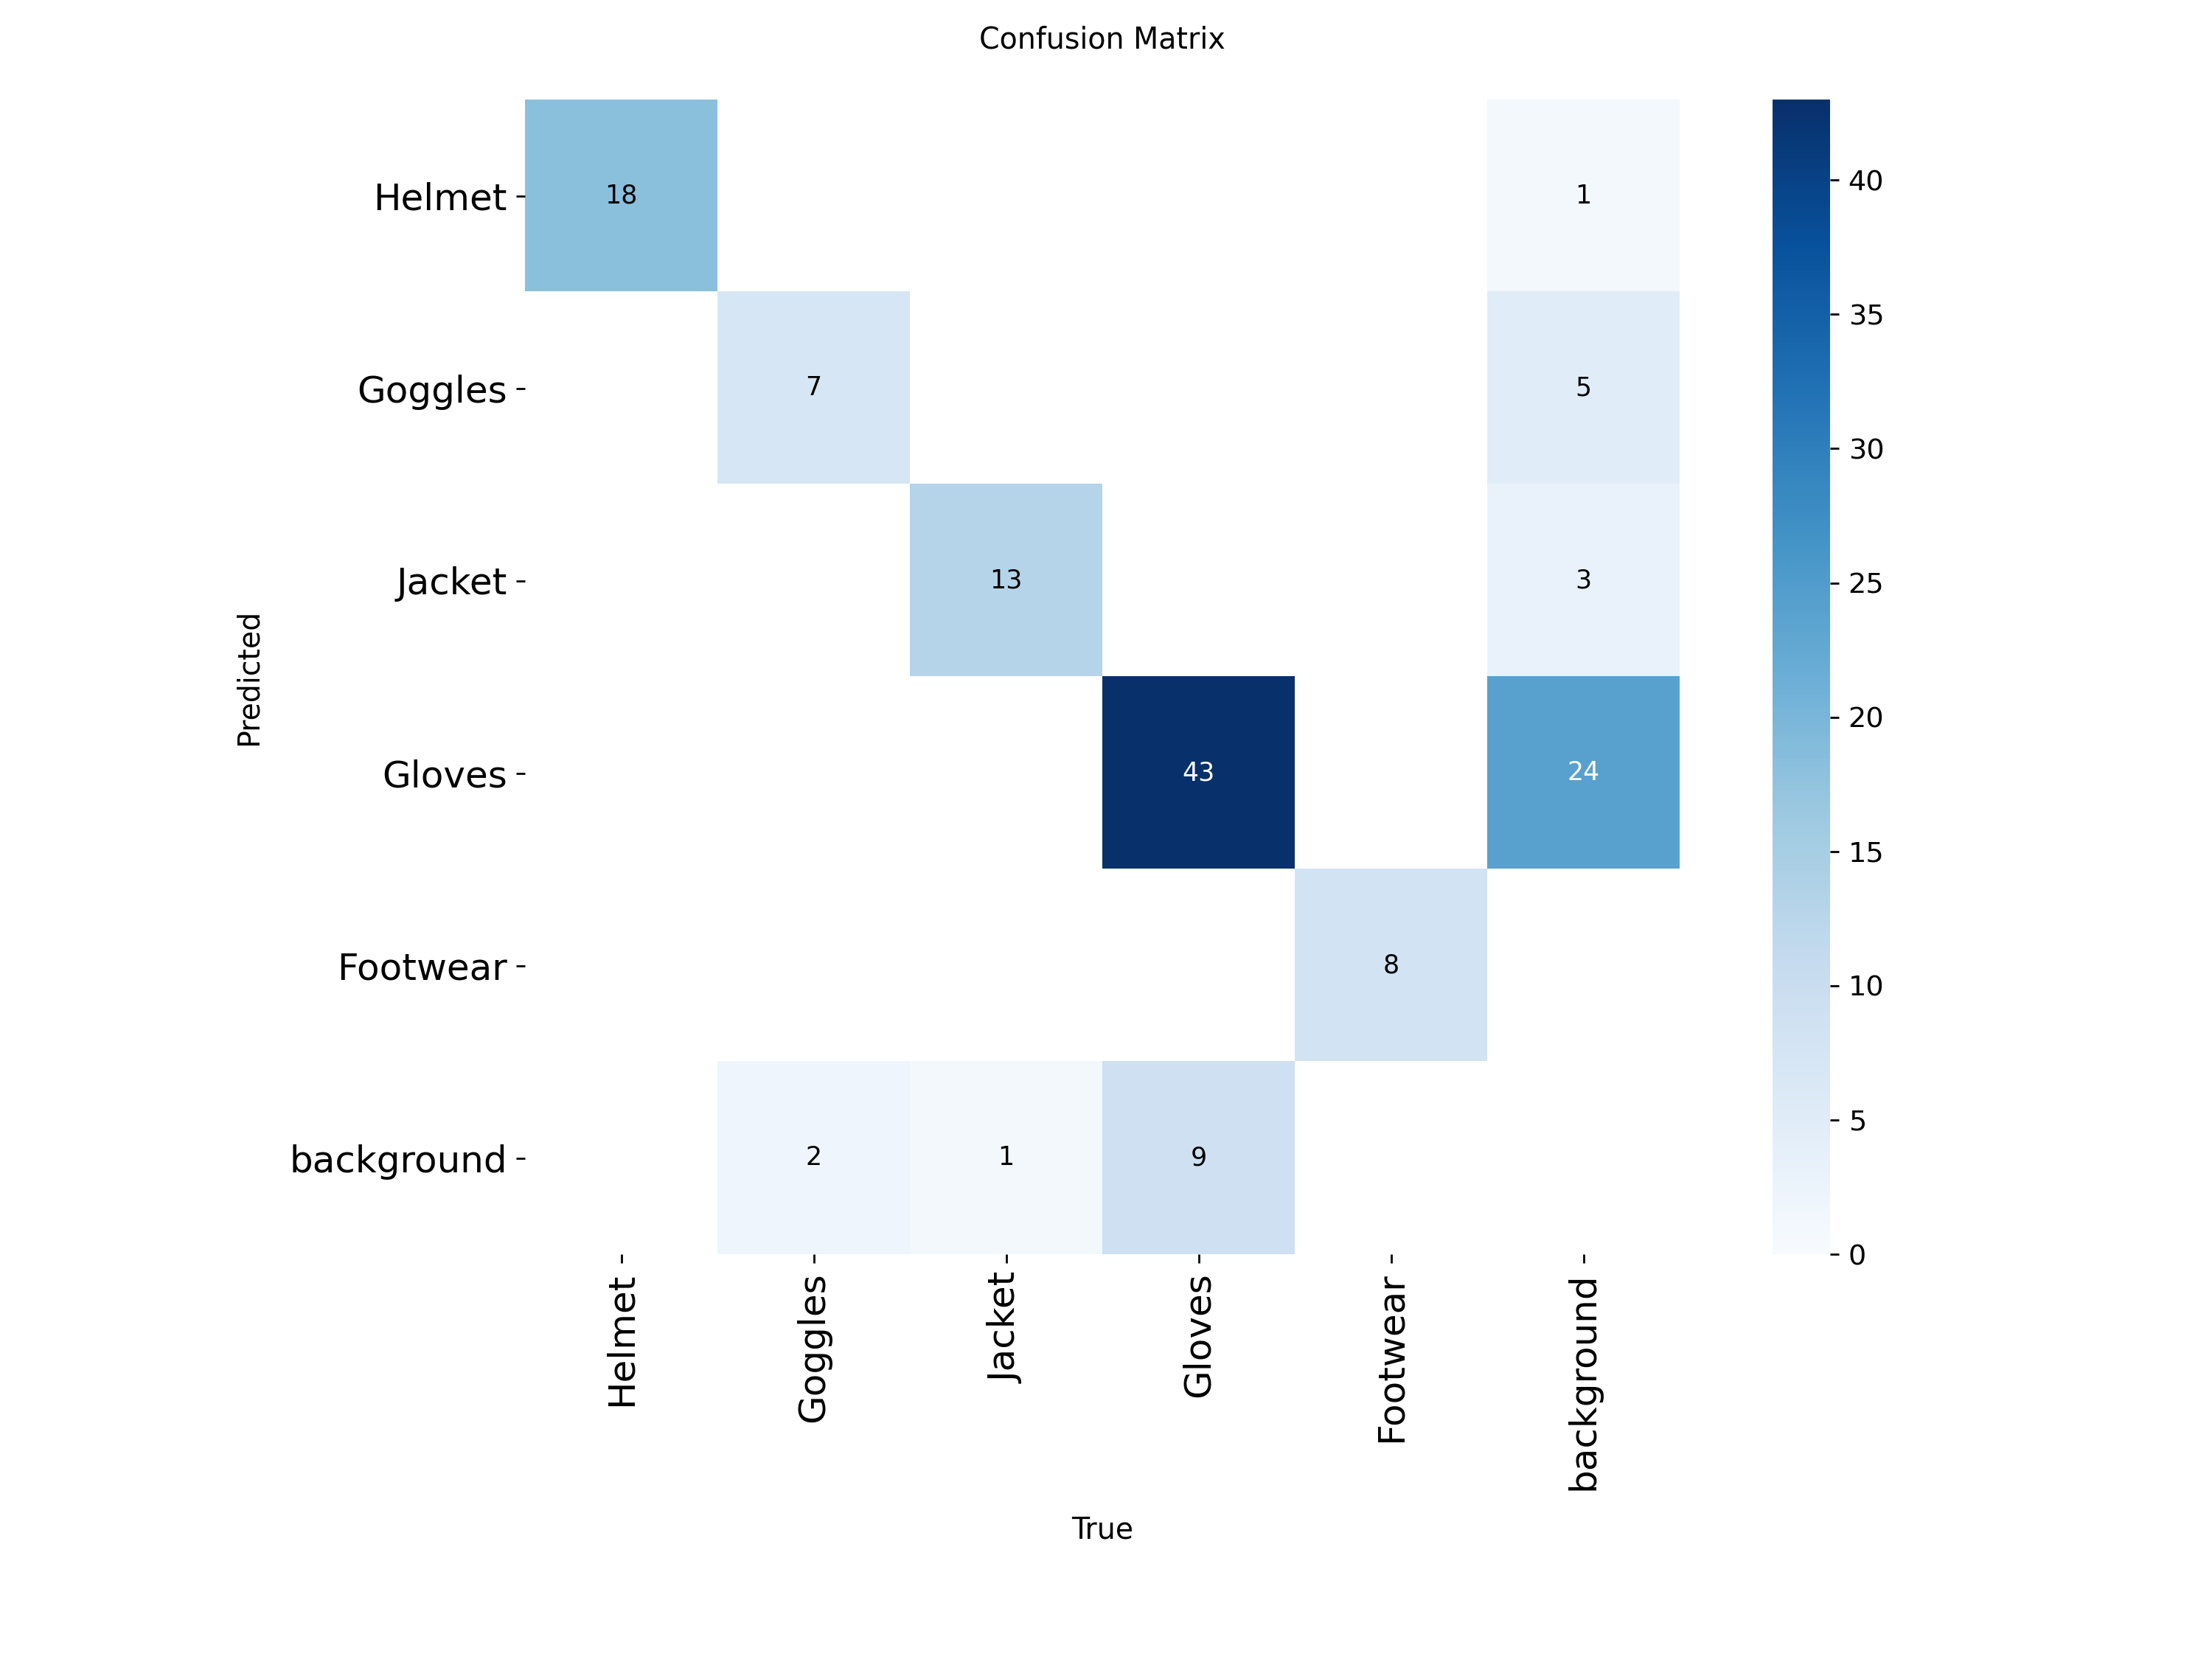

In [9]:
Image(filename='/content/drive/MyDrive/Computer vision/Day 23/runs/detect/train/confusion_matrix.png', width=600)

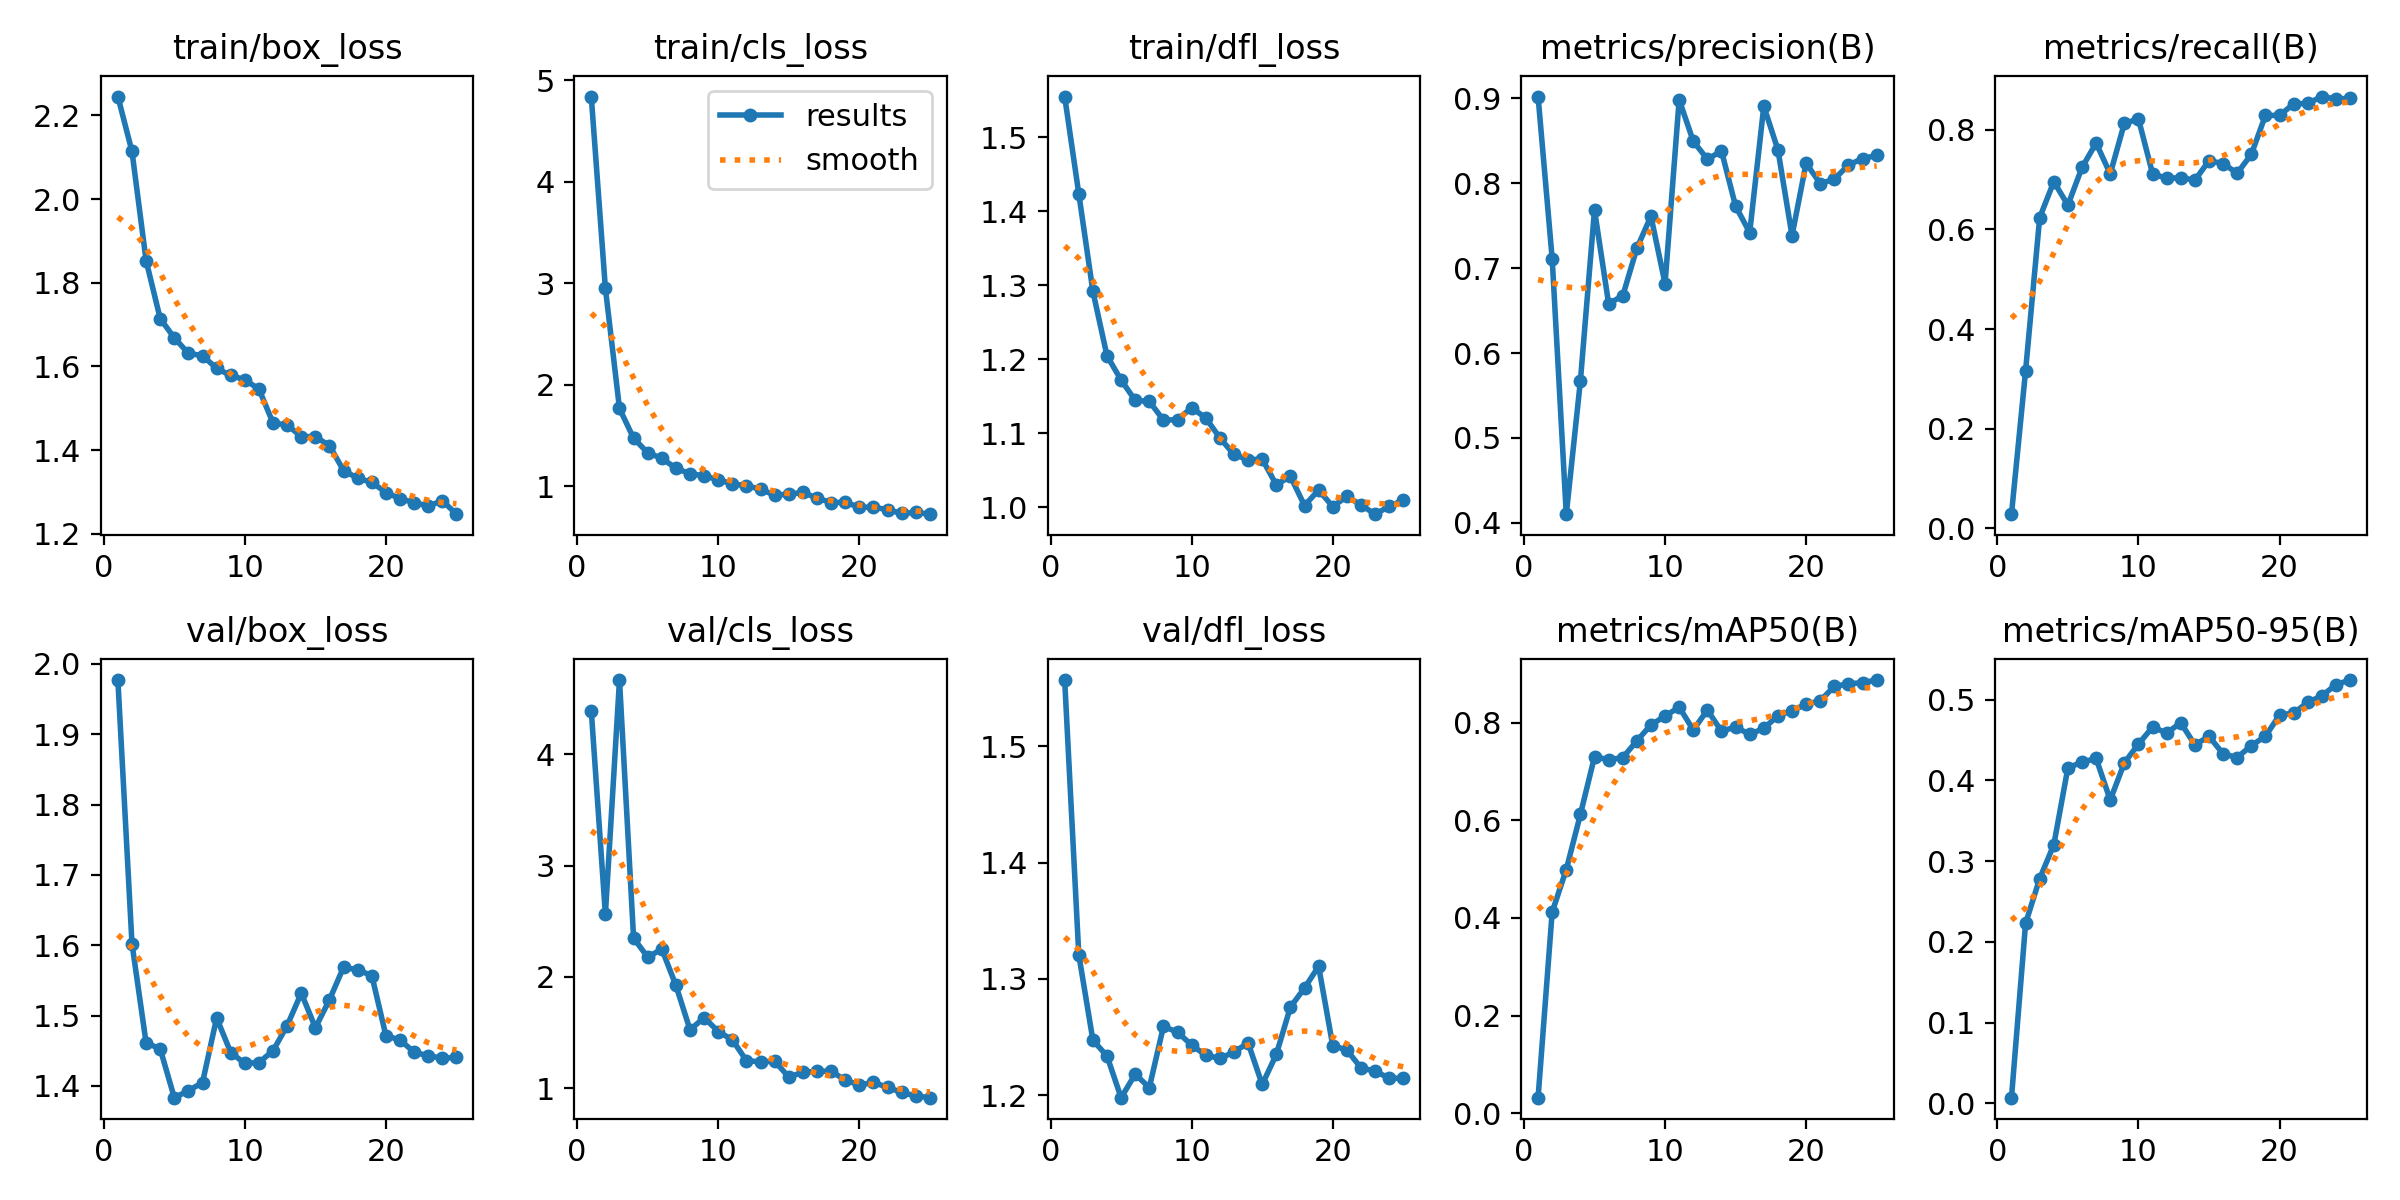

In [10]:
Image(filename='/content/drive/MyDrive/Computer vision/Day 23/runs/detect/train/results.png', width=600)

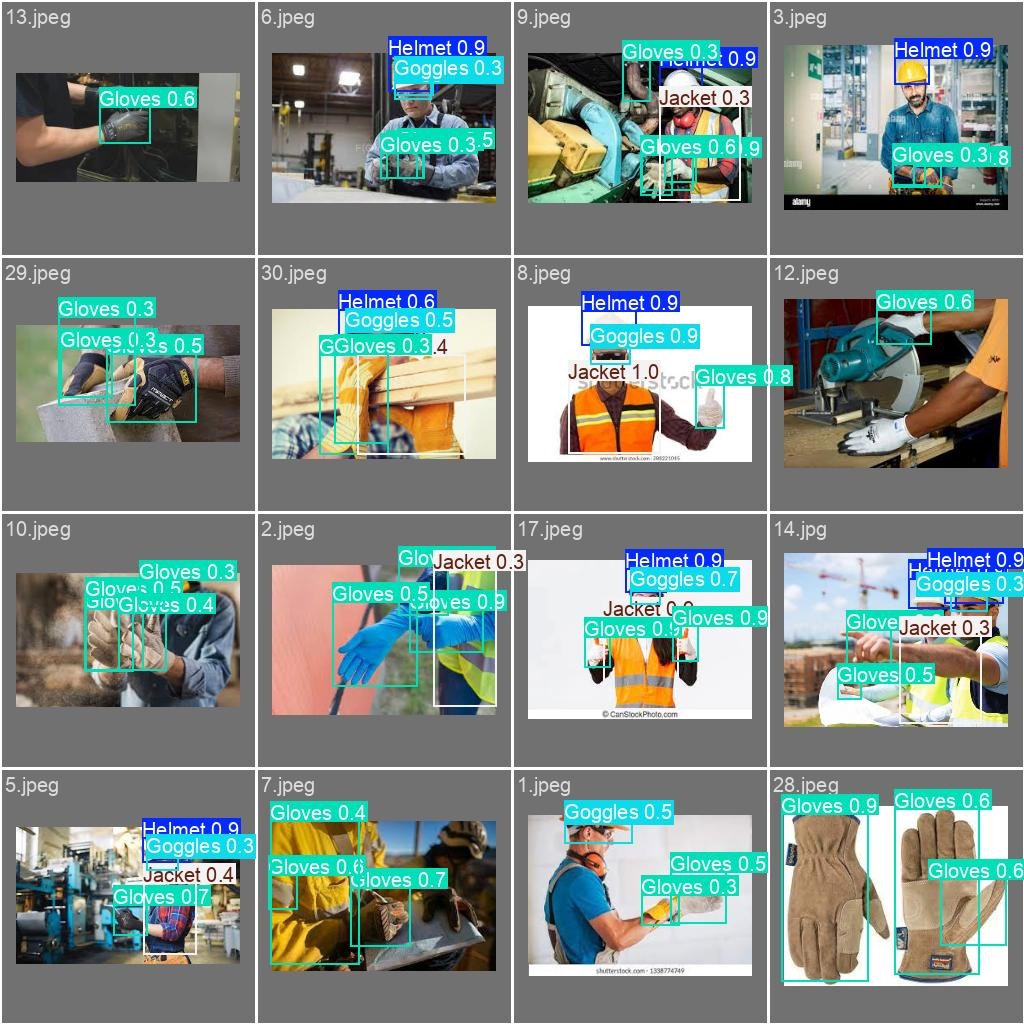

In [11]:
Image(filename='/content/drive/MyDrive/Computer vision/Day 23/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [12]:
!yolo task=detect mode=val model="/content/drive/MyDrive/Computer vision/Day 23/runs/detect/train/weights/best.pt" data=data.yaml

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.0±0.0 MB/s, size: 8.1 KB)
val: Scanning /content/drive/MyDrive/Computer vision/Day 23/valid/labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 6.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.1s/it 10.1s
                   all         31        101      0.859      0.882      0.894      0.526
                Helmet         17         18      0.917          1      0.995      0.715
               Goggles          9          9      0.683       0.72      0.735      0.326
                Jacket         13         14          1      0.883      0.951      0.684
                Gloves         30         52      0.741      0.808      0.795      0.412
              Footwear       

## Inference with Custom Model

In [13]:
!yolo task=detect mode=predict model="/content/drive/MyDrive/Computer vision/Day 23/runs/detect/train/weights/best.pt" conf=0.25 source="/content/drive/MyDrive/Computer vision/Day 23/test/images"

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs

image 1/31 /content/drive/MyDrive/Computer vision/Day 23/test/images/1.jpeg: 192x224 1 Goggles, 2 Glovess, 49.0ms
image 2/31 /content/drive/MyDrive/Computer vision/Day 23/test/images/10.jpeg: 160x224 3 Glovess, 46.4ms
image 3/31 /content/drive/MyDrive/Computer vision/Day 23/test/images/11.jpeg: 224x224 3 Glovess, 8.9ms
image 4/31 /content/drive/MyDrive/Computer vision/Day 23/test/images/12.jpeg: 192x224 3 Glovess, 10.3ms
image 5/31 /content/drive/MyDrive/Computer vision/Day 23/test/images/13.jpeg: 128x224 1 Gloves, 69.6ms
image 6/31 /content/drive/MyDrive/Computer vision/Day 23/test/images/14(1).jpeg: 224x224 1 Gloves, 12.9ms
image 7/31 /content/drive/MyDrive/Computer vision/Day 23/test/images/14.jpg: 192x224 2 Helmets, 1 Goggles, 1 Jacket, 2 Glovess, 12.3ms
image 8/31 /content/drive/MyDrive/Computer vision/Day 23/test/ima

**NOTE:** Let's take a look at few results.